# 06 — Macro factors from point-in-time market data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/06_macro_factors.ipynb)

No target other than the history: seven monthly factor excess returns are built
at run time from public market series, and the sample itself is the target.
The question is whether each generator reproduces this factor history, tails included.

Runtime: about 3 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import Targets, CVineMarket, FleishmanMarket, load_factor_data

cvinemarketgen 0.2.0


## Load the factors

| Factor | Construction | Source |
|---|---|---|
| Equity DM | developed-market excess return, Mkt-RF | Fama-French |
| Equity EM | emerging minus developed excess return | Fama-French |
| Real premia | carry − 8 × change of the 10y TIPS real yield | FRED |
| Inflation | carry + 8 × change of the 10y breakeven | FRED |
| Credit | carry − 10 × change of the Baa − 10y spread | FRED |
| Commodity | DBC ETF total return minus the risk-free rate | Yahoo Finance |
| Small cap | U.S. small minus big, SMB | Fama-French |

The download is cached in `data/factors_cache.csv`.

In formulas, with $t$ a month and all returns monthly decimals. Equity DM is the Fama-French developed-market excess return, $f^{DM}_t = \mathrm{Mkt}_t - \mathrm{RF}_t$; Equity EM is the emerging minus developed excess return, $f^{EM}_t = (\mathrm{Mkt} - \mathrm{RF})^{EM}_t - (\mathrm{Mkt} - \mathrm{RF})^{DM}_t$; Small cap is SMB. The three yield-based factors are long/short positions on a daily FRED series $y_t$ (a yield or a spread in percent), taken at the month end and divided by 100, with a fixed duration $D$:

$$
f_t = \frac{y_{t-1}}{12} + s\, D\, (y_t - y_{t-1}),
$$

the first term the carry over the month and the second the price effect of the yield change. Real premia uses the 10-year TIPS real yield with $s = -1$ and $D = 8$ (a long TIPS position loses when the real yield rises); Inflation uses the 10-year breakeven with $s = +1$ and $D = 8$ (long TIPS, short nominal: gains when the breakeven rises); Credit uses the Baa minus 10-year Treasury spread with $s = -1$ and $D = 10$. Commodity is the DBC total return minus the risk-free rate, $P_t / P_{t-1} - 1 - \mathrm{RF}_t$. The seven series are aligned on their common months.

In [2]:
factors = load_factor_data(start="2006-03", cache=os.path.join(ROOT, "data", "factors_cache.csv"))
factors.head()

factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07


,Equity DM,Equity EM,Real premia,Inflation,Credit,Commodity,Small cap
month,,,,,,,
2006-04,0.0287,0.0434,-0.001242,0.015692,0.003408,0.066575,-0.0138
2006-05,-0.0412,-0.0619,-0.005208,-0.000967,0.002392,-0.008203,-0.0301
2006-06,-0.0059,-0.0085,-0.002733,-0.000200,0.000383,-0.012621,-0.0035
2006-07,-0.0025,0.0112,0.012517,-0.000225,0.000392,0.018135,-0.0396
2006-08,0.0223,0.0037,0.015608,-0.004250,-0.003600,-0.037456,0.0099


## Look at the data before modelling it

Sample moments of the $n$ monthly observations, annualized the usual way: the mean $12\,\bar f$ and the volatility $\sqrt{12}\, s$, with $\bar f = \frac{1}{n}\sum_t f_t$ and $s^2 = \frac{1}{n-1}\sum_t (f_t - \bar f)^2$. Skewness and kurtosis are not annualized: they are the bias-adjusted sample estimators of pandas, $\hat\gamma_1 \approx \frac{1}{n}\sum_t \big((f_t - \bar f)/s\big)^3$ and $\hat\gamma_2 \approx \frac{1}{n}\sum_t \big((f_t - \bar f)/s\big)^4$, the kurtosis reported raw (normal $= 3$), which is the convention of the targets.

In [3]:
pd.concat([factors.mean().mul(12).rename("mean (ann.)"), factors.std().mul(12 ** 0.5).rename("vol (ann.)"),
           factors.skew().rename("skew"), (factors.kurtosis() + 3).rename("kurt")], axis=1).round(3)

,mean (ann.),vol (ann.),skew,kurt
Equity DM,0.080,0.158,-0.641,4.735
Equity EM,-0.007,0.108,-0.024,2.987
Real premia,0.008,0.062,-0.633,5.405
Inflation,0.020,0.047,0.133,9.561
Credit,0.025,0.082,-1.910,17.585
Commodity,0.023,0.188,-0.531,4.963
Small cap,-0.009,0.086,0.318,3.031


The Pearson correlation matrix of the seven factors, $\hat\Sigma_{ik} = \frac{\sum_t (f_{i,t} - \bar f_i)(f_{k,t} - \bar f_k)}{(n-1)\, s_i s_k}$; it is the correlation target $\Sigma^*$ that the generators will be asked to reproduce.

In [4]:
factors.corr().round(2)

,Equity DM,Equity EM,Real premia,Inflation,Credit,Commodity,Small cap
Equity DM,1.00,0.10,0.30,0.51,0.61,0.51,0.28
Equity EM,0.10,1.00,0.13,0.18,0.21,0.25,-0.02
Real premia,0.30,0.13,1.00,0.21,-0.02,0.11,0.01
Inflation,0.51,0.18,0.21,1.00,0.56,0.58,0.20
Credit,0.61,0.21,-0.02,0.56,1.00,0.44,0.24
Commodity,0.51,0.25,0.11,0.58,0.44,1.00,0.10
Small cap,0.28,-0.02,0.01,0.20,0.24,0.10,1.00


The growth of one unit invested in each factor, $\prod_{s \le t} (1 + f_s)$: the 2008 drawdown of the credit and equity factors is the episode that gives them their tails.

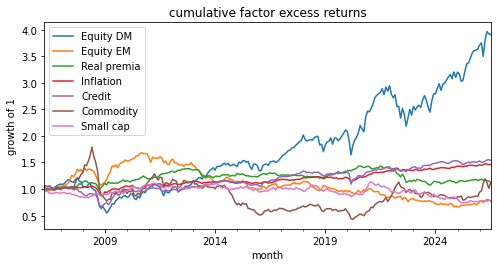

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.8))
(1 + factors).cumprod().plot(ax=ax); ax.set_title("cumulative factor excess returns"); ax.set_ylabel("growth of 1"); plt.show()

## Targets are the sample

`Targets.from_history` reads every target off the sample: $\mu_i = \bar f_i$, $\sigma_i = s_i$, $\Sigma^* = \hat\Sigma$, and the higher moments $\gamma_{1,i} = \hat\gamma_{1,i}$, $\gamma_{2,i} = \hat\gamma_{2,i}$, all in monthly units, with the history itself kept for the selection of the copula families. The generators are then asked to reproduce the sample, and the test is whether they do so tails included.

In [6]:
t = Targets.from_history(factors)
t.summary();

Targets for 7 assets (returns layer, history frequency M)
               mean     vol    skew     kurt
Equity DM    0.0066  0.0455 -0.6413   4.7346
Equity EM   -0.0006  0.0311 -0.0237   2.9870
Real premia  0.0007  0.0179 -0.6329   5.4048
Inflation    0.0017  0.0135  0.1327   9.5613
Credit       0.0021  0.0237 -1.9096  17.5847
Commodity    0.0020  0.0543 -0.5306   4.9626
Small cap   -0.0007  0.0248  0.3184   3.0306

correlation matrix:
             Equity DM  Equity EM  Real premia  Inflation  Credit  Commodity  Small cap
Equity DM         1.00       0.10         0.30       0.51    0.61       0.51       0.28
Equity EM         0.10       1.00         0.13       0.18    0.21       0.25      -0.02
Real premia       0.30       0.13         1.00       0.21   -0.02       0.11       0.01
Inflation         0.51       0.18         0.21       1.00    0.56       0.58       0.20
Credit            0.61       0.21        -0.02       0.56    1.00       0.44       0.24
Commodity         0.51       0.25

## C-vine generator, families from the history

With Equity DM as the central node, `fit` runs the algorithms of the paper: Johnson SU marginals $X_i = \mu_i + \sigma_i\, q_i(Z)$, $q_i(z) = \xi_i + \lambda_i \sinh\!\big((z - \gamma_i)/\delta_i\big)$, with parameters solving the four moment equations; family selection per edge from the exceedance-correlation signature $(\ell, u, s, m)$ of the pair on the history, the lowest-BIC family whose tail coefficients $(\lambda_L, \lambda_U)$ match; and calibration of the parameters, variable by variable,

$$
\hat{\boldsymbol\theta}_i = \arg\min_{\boldsymbol\theta_i} \sum_{k < i} \Big( \mathrm{Corr}\big(F_i^{-1}(u_i(\boldsymbol\theta_i)),\, F_k^{-1}(u_k)\big) - \Sigma^*_{ik} \Big)^2 .
$$

`edges` gives the selected family, rotation and parameters of the six first-tree edges (each factor against Equity DM) and of the fifteen deeper edges $C_{ik \mid 1:k-1}$.

In [7]:
t0 = time.time()
cv = CVineMarket(t, central="Equity DM", families="auto").fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.edges

fit: 168 s


,tree,edge,selected family,parameters
0,1,"Equity EM , Equity DM",gumbel 180°,theta=1.069
1,1,"Real premia , Equity DM",gumbel 180°,theta=1.211
2,1,"Inflation , Equity DM",gumbel 180°,theta=1.512
3,1,"Credit , Equity DM",gumbel 180°,theta=1.649
4,1,"Commodity , Equity DM",gumbel 180°,theta=1.484
5,1,"Small cap , Equity DM",gumbel 0°,theta=1.220
6,2,"Real premia , Equity EM | Equity DM",clayton 180°,theta=0.141
7,2,"Inflation , Equity EM | Equity DM",clayton 180°,theta=0.182
8,2,"Credit , Equity EM | Equity DM",gumbel 0°,theta=1.135
9,2,"Commodity , Equity EM | Equity DM",gumbel 0°,theta=1.162


Algorithm 5: $25{,}000$ uniform vectors from the calibrated vine, the marginals re-fitted on the draw, scenarios $X_i = \mu_i + \sigma_i\, q_i(\Phi^{-1}(U_i))$, and the draw accepted when every moment and correlation is within tolerance ($2 \times 10^{-4}$ on means and volatilities, $5 \times 10^{-2}$ on skewness and kurtosis, $\tau = 0.05$ on correlations). The diagnostics table shows target, simulated and difference per moment, and the largest entry of $\hat\Sigma - \Sigma^*$.

In [8]:
X = cv.simulate(25000, seed=1)
cv.diagnostics(X).summary();

25000 simulated observations (returns layer)
             mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
Equity DM         0.0066          0.0066        0.0      0.0455         0.0455    0.0000      -0.6413         -0.6413    -0.0000       4.7346          4.7352     0.0006
Equity EM        -0.0006         -0.0006        0.0      0.0311         0.0313    0.0002      -0.0237          0.0180     0.0418       2.9870          3.0214     0.0344
Real premia       0.0007          0.0007       -0.0      0.0179         0.0179    0.0000      -0.6329         -0.6329    -0.0000       5.4048          5.4055     0.0007
Inflation         0.0017          0.0017       -0.0      0.0135         0.0135    0.0000       0.1327          0.1327     0.0000       9.5613          9.5629     0.0016
Credit            0.0021          0.0021        0.0      0.0237         0.0237    0.0000      -1.9096         

## Fleishman generator and the exceedance curves against the actual history

The Fleishman generator on the same targets: $X_i = \mu_i + \sigma_i (a_i + b_i Z_i + c_i Z_i^2 + d_i Z_i^3)$ with the coefficients solving the moment equations for $(0, 1, \gamma_{1,i}, \gamma_{2,i})$, and Gaussian dependence through the Vale-Maurelli intermediate correlations $\rho_Z$ solving

$$
\Sigma^*_{ik} = \rho_Z\,(b_i b_k + 3 b_i d_k + 3 d_i b_k + 9 d_i d_k) + 2\,\rho_Z^2\, c_i c_k + 6\,\rho_Z^3\, d_i d_k
$$

for each pair. The credit factor's kurtosis (above 17) is inside the feasible region $\gamma_2 - 3 \ge \gamma_1^2 - 2$, so every marginal has a solution. The printed diagnostics are the same four moments and the correlation error.

In [9]:
fm = FleishmanMarket(t).fit()
Xf = fm.simulate(25000, seed=1)
print(fm.diagnostics(Xf))

Diagnostics(n=25000, max |corr error|=0.0124, mean 1.3e-17, vol 1.1e-06, skew 1.1e-04, kurt 3.2e-03)


Exceedance correlation of each factor against Equity DM, for thresholds $z$ from $-1$ to $1$ standard deviations:

$$
\hat\rho(z) = \mathrm{Corr}\big(f^{DM}, f_i \,\big|\, \tilde f^{DM} \le z\big) \ \text{for } z < 0, \qquad \hat\rho(z) = \mathrm{Corr}\big(f^{DM}, f_i \,\big|\, \tilde f^{DM} \ge z\big) \ \text{for } z \ge 0,
$$

with $\tilde f^{DM} = (f^{DM} - \bar f^{DM}) / s^{DM}$. A Gumbel rotated by 180 degrees has lower-tail dependence $\lambda_L = 2 - 2^{1/\theta}$ and upper-tail dependence zero, so its curve is higher on the left of zero than on the right; the Gaussian copula of the Fleishman generator has $\lambda_L = \lambda_U = 0$ and a symmetric curve. The black curve is the actual history, the two others the 25,000 scenarios of each generator.

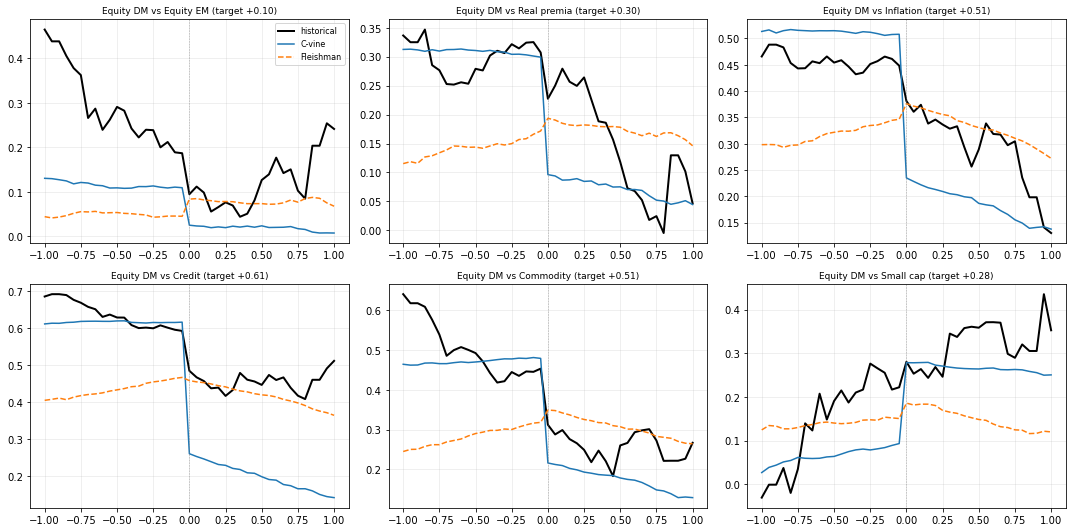

In [10]:
from cvinemarketgen import exceedance_curve
z = np.round(np.arange(-1, 1.001, 0.05), 3)
others = [a for a in t.assets if a != "Equity DM"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5)); axes = list(axes.flat)
for ax, a in zip(axes, others):
    for name, df, st in [("historical", factors, dict(color="black", lw=2)), ("C-vine", X, dict(color="tab:blue")), ("Fleishman", Xf, dict(color="tab:orange", ls="--"))]:
        ax.plot(z, exceedance_curve(df["Equity DM"], df[a], z).values, label=name, **st)
    ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_title(f"Equity DM vs {a} (target {t.corr.loc['Equity DM', a]:+.2f})", fontsize=9); ax.grid(alpha=0.25)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## Reading the results

Five of the six first-tree edges receive a Gumbel 180°: Equity EM, Real premia,
Inflation, Credit and Commodity show lower-tail dependence with Equity DM in
this sample. Small cap is the exception with a Gumbel 0°: small-cap
outperformance clusters with strong equity months rather than with crashes.
The C-vine reproduces the jump at zero on all six pairs; the Fleishman
generator, with Gaussian dependence, cannot. The 2008 episode makes the credit
factor extremely heavy-tailed (kurtosis above 17), which both marginal models
accommodate.